In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import zipfile
import os

In [3]:

from google.colab import files
uploaded = files.upload()


zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted successfully!")

Saving Pharmaceutical Supply Chain Optimization.zip to Pharmaceutical Supply Chain Optimization.zip
Files extracted successfully!


In [4]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    for file in files:
        print(file)

Pharmaceutical Supply Chain Optimization.xlsx


In [5]:
# Check extracted files
for root, dirs, files_ in os.walk("dataset"):
    for file in files_:
        print(os.path.join(root,file))

dataset/Pharmaceutical Supply Chain Optimization.xlsx


In [6]:
df = pd.read_excel("/content/dataset/Pharmaceutical Supply Chain Optimization.xlsx")

df.head(50)

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly
5,Metformin,3617,2978,Monthly
6,Insulin,7273,7951,Monthly
7,Insulin,9653,2208,Monthly
8,Metformin,2488,3968,Monthly
9,Atorvastatin,2045,2408,Quarterly


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.info()

Shape: (100000, 4)

Columns:
Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level',
       'Restocking_Strategy'],
      dtype='object')

Data Types:
Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object

Missing Values:
Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (100000, 4)


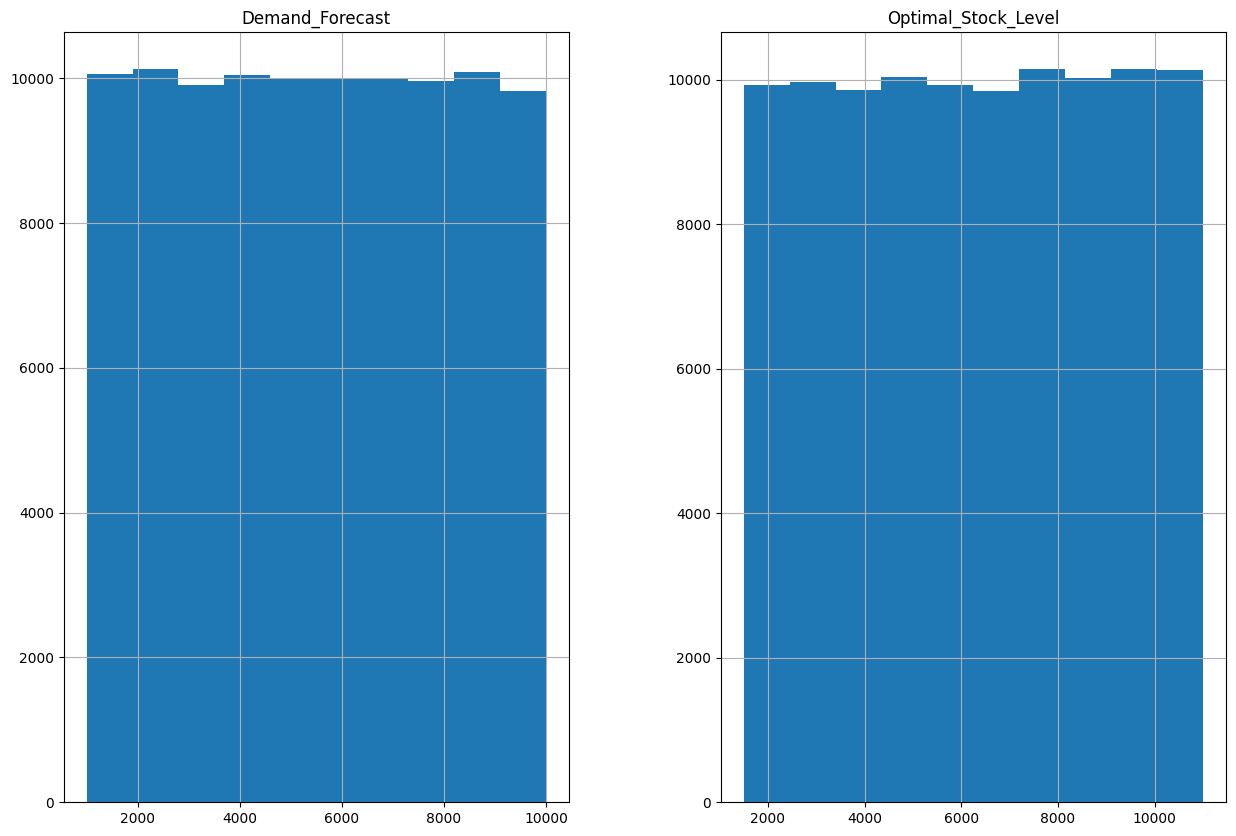

In [9]:
df.hist(figsize=(15,10))
plt.show()

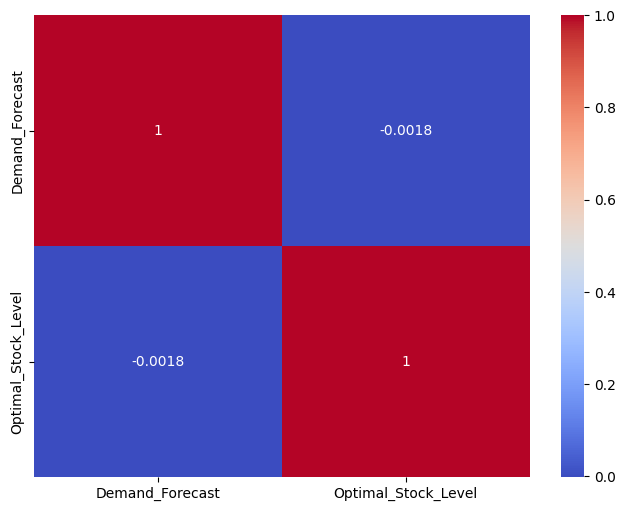

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

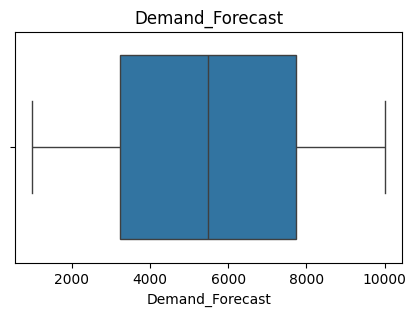

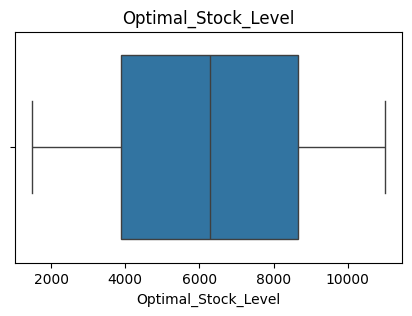

In [11]:
for col in num_cols:

    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [12]:
encoder = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,3,7750,4753,0
1,2,5136,9965,1
2,3,3183,2933,0
3,1,2332,3927,0
4,0,3522,6812,0


In [13]:
target = 'Demand_Forecast'

X = df.drop(target, axis=1)
y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(
    mean_squared_error(y_test,pred_lr)
)

r2_lr = r2_score(y_test,pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 2598.772913238471
Linear Regression R2: 1.7462346059482492e-05


In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(
    mean_squared_error(y_test,pred_rf)
)

r2_rf = r2_score(y_test,pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 3004.8631520180306
Random Forest R2: -0.33691916574707603


In [17]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(
    mean_squared_error(y_test,pred_gb)
)

r2_gb = r2_score(y_test,pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R2:", r2_gb)

Gradient Boosting RMSE: 2600.495132270546
Gradient Boosting R2: -0.0013083630853780726


In [18]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "RMSE":[
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],

    "R2":[
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

comparison

,Model,RMSE,R2
0,Linear Regression,2598.772913,0.000017
1,Random Forest,3004.863152,-0.336919
2,Gradient Boosting,2600.495132,-0.001308


In [19]:
params = {

    'n_estimators':[100,200],

    'max_depth':[5,10,None],

    'min_samples_split':[2,5]
}

In [20]:
grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid=params,

    cv=5,

    scoring='neg_mean_squared_error',

    n_jobs=-1
)

In [23]:

X_train_sample = X_train[:10000]
y_train_sample = y_train[:10000]

grid.fit(X_train_sample, y_train_sample)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [24]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [25]:
best_rf = grid.best_estimator_

pred_best = best_rf.predict(X_test)

best_rmse = np.sqrt(
    mean_squared_error(y_test,pred_best)
)

best_r2 = r2_score(
    y_test,
    pred_best
)

print("Tuned Random Forest RMSE:", best_rmse)
print("Tuned Random Forest R2:", best_r2)

Tuned Random Forest RMSE: 2600.599531752346
Tuned Random Forest R2: -0.001388761753526646


In [26]:
scores = cross_val_score(

    best_rf,

    X,

    y,

    cv=5,

    scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores

print("Cross Validation RMSE Scores:")
print(rmse_scores)

print("Average RMSE:")
print(rmse_scores.mean())

Cross Validation RMSE Scores:
[2610.12521329 2600.43479774 2592.09736411 2594.84964685 2592.93514686]
Average RMSE:
2598.088433772279


In [27]:
print("============== FINAL RESULT ==============")

print("Linear Regression RMSE:", rmse_lr)

print("Random Forest RMSE:", rmse_rf)

print("Gradient Boosting RMSE:", rmse_gb)

print("Tuned Random Forest RMSE:", best_rmse)

print("Cross Validation RMSE:", rmse_scores.mean())

============== FINAL RESULT ==============
Linear Regression RMSE: 2598.772913238471
Random Forest RMSE: 3004.8631520180306
Gradient Boosting RMSE: 2600.495132270546
Tuned Random Forest RMSE: 2600.599531752346
Cross Validation RMSE: 2598.088433772279
